# Data source: https://huggingface.co/datasets/creative-graphic-design/GraphicDesignEvaluation

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:

print("⏳ Đang load 3 datasets (alignment / overlap / whitespace)...")

df_alignment = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-alignment/train-00000-of-00001.parquet")
df_overlap = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-overlap/train-00000-of-00001.parquet")
df_whitespace = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-whitespace/train-00000-of-00001.parquet")

# Đặt tên label rõ ràng
df_alignment['label']  = df_alignment['avg'].astype(float)
df_overlap['label']    = df_overlap['avg'].astype(float)
df_whitespace['label'] = df_whitespace['avg'].astype(float)

print(f"   alignment  : {len(df_alignment):>4} mẫu  | label range: {df_alignment['label'].min():.1f} – {df_alignment['label'].max():.1f}")
print(f"   overlap    : {len(df_overlap):>4} mẫu  | label range: {df_overlap['label'].min():.1f} – {df_overlap['label'].max():.1f}")
print(f"   whitespace : {len(df_whitespace):>4} mẫu  | label range: {df_whitespace['label'].min():.1f} – {df_whitespace['label'].max():.1f}")
print("✅ Load xong!")


⏳ Đang load 3 datasets (alignment / overlap / whitespace)...
   alignment  :  400 mẫu  | label range: 2.4 – 9.0
   overlap    :  400 mẫu  | label range: 2.0 – 8.4
   whitespace :  400 mẫu  | label range: 2.0 – 8.0
✅ Load xong!


C:\Users\HP\AppData\Local\Temp\ipykernel_3612\1567388941.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


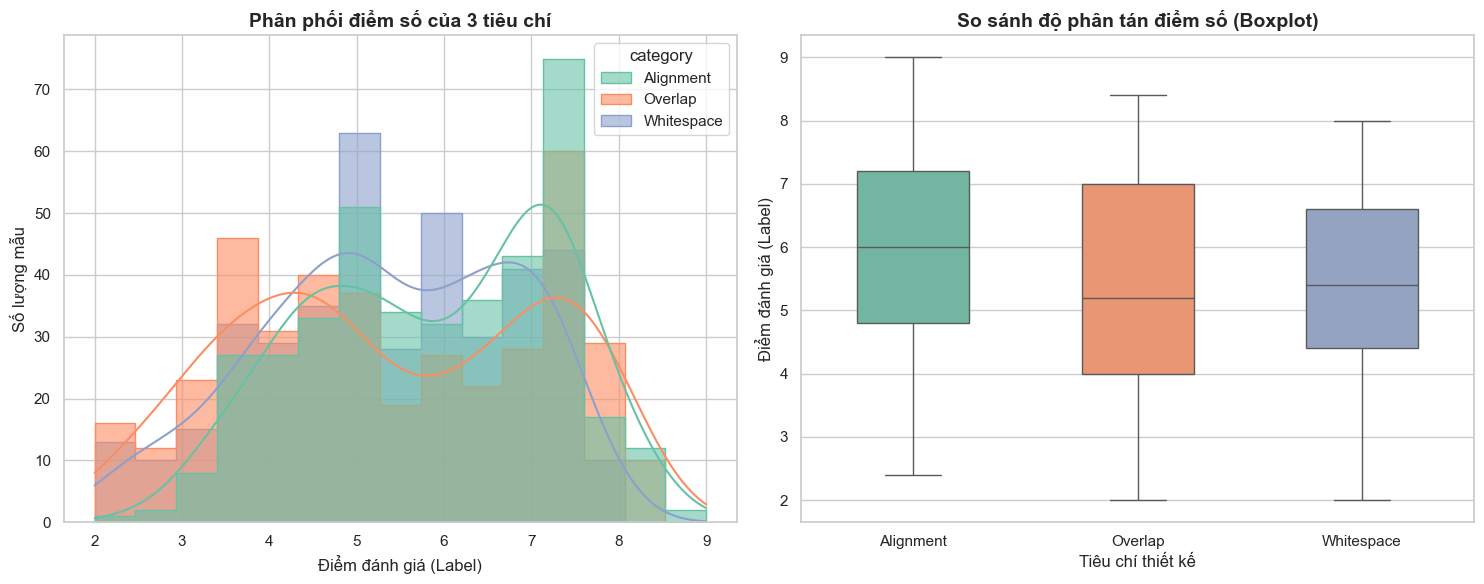

In [9]:
# 1. Chuẩn bị dữ liệu (Gộp 3 DataFrame để dễ vẽ bằng Seaborn)
df_alignment['category'] = 'Alignment'
df_overlap['category'] = 'Overlap'
df_whitespace['category'] = 'Whitespace'

# Chỉ lấy cột 'label' và 'category' để tối ưu bộ nhớ
df_combined = pd.concat([
    df_alignment[['label', 'category']],
    df_overlap[['label', 'category']],
    df_whitespace[['label', 'category']]
], ignore_index=True)

# 2. Thiết lập không gian vẽ biểu đồ (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid") # Thêm lưới cho dễ nhìn

# --- Biểu đồ 1: Biểu đồ phân phối (Histogram + Đường mật độ KDE) ---
sns.histplot(
    data=df_combined,
    x='label',
    hue='category',
    kde=True,
    ax=axes[0],
    palette='Set2',
    alpha=0.6,
    element="step"
)
axes[0].set_title('Phân phối điểm số của 3 tiêu chí', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Điểm đánh giá (Label)', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)

# --- Biểu đồ 2: Biểu đồ hộp (Boxplot) ---
sns.boxplot(
    data=df_combined,
    x='category',
    y='label',
    ax=axes[1],
    palette='Set2',
    width=0.5
)
axes[1].set_title('So sánh độ phân tán điểm số (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiêu chí thiết kế', fontsize=12)
axes[1].set_ylabel('Điểm đánh giá (Label)', fontsize=12)

# 3. Hiển thị biểu đồ
plt.tight_layout()
plt.show()